# 4-class flight delay prediction (Aeolus 2024)
Run the cells **one by one, top to bottom**. Start with `QUICK = True` (Part 1) to check everything works, then set `QUICK = False` and run again from Part 1.

What is new compared with your first version:
1. **Context features (Part 3):** recent delay at the origin airport, destination airport and airline, plus scheduled traffic. Built only from flights that were scheduled at least 3 hours earlier. This is the main source of better macro-F1.
2. **Early-stopping fix (Part 6):** the validation loss now uses the same class weights as training. Before, the boosted models stopped after a few trees (about 5 seconds), so they were barely trained.
3. **Wider multiplier search (Part 7)** and a baseline row ("always On-time") so you can see what a real improvement is.

## Part 1 - Imports and settings

In [1]:
from pathlib import Path
import time, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             precision_score, recall_score, matthews_corrcoef,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool
warnings.filterwarnings("ignore")

PROJECT_DIR = Path(r"D:\Y3S2\FDM\assignment\New folder")
CSV_PATH = PROJECT_DIR / "data" / "flight_with_weather_2024.csv"

QUICK = True     # True = fast check (small samples, no TEST).  False = final run + TEST.

OUTPUT_DIR = PROJECT_DIR / ("outputs_quick" if QUICK else "outputs_4class")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
CLASS_NAMES = ["On-time", "Minor", "Moderate", "Severe"]
LABELS = [0, 1, 2, 3]
BINS = [15, 45, 120]                       # <15, 15-44, 45-119, >=120 minutes

TRAIN_END = pd.Timestamp("2024-08-31")     # train: Jan-Aug
VAL_END = pd.Timestamp("2024-10-31")       # valid: Sep-Oct ; test: Nov-Dec

TRAIN_LIMIT = 100_000 if QUICK else 500_000
VAL_LIMIT = 30_000 if QUICK else 200_000
RF_LIMIT = 30_000 if QUICK else 150_000

LAG_H = 3  # Hours of lag used for historical delay features

# DEP_DELAY is loaded ONLY to build the "recent delay" context features of OTHER flights.
# It is never used as a feature of the flight being predicted (see make_features in Part 4).
LOAD_COLS = ["FL_DATE", "OP_CARRIER", "ORIGIN", "DEST",
             "CRS_DEP_TIME", "CRS_ARR_TIME", "CRS_ELAPSED_TIME",
             "MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK",
             "O_TEMP", "O_PRCP", "O_WSPD", "D_TEMP", "D_PRCP", "D_WSPD",
             "O_LATITUDE", "O_LONGITUDE", "D_LATITUDE", "D_LONGITUDE",
             "DEP_DELAY", "ARR_DELAY"]

print("CSV exists:", CSV_PATH.exists())
print("Mode:", "QUICK CHECK" if QUICK else "FINAL TRAINING")

CSV exists: True
Mode: QUICK CHECK


## Part 2 - Load and clean the data

In [2]:
TIME_COLS = ["CRS_DEP_TIME", "CRS_ARR_TIME"]

df = pd.read_csv(CSV_PATH, usecols=LOAD_COLS, low_memory=False,
                 dtype={"CRS_DEP_TIME": "string", "CRS_ARR_TIME": "string"})
print("Raw time values:")
print(df[TIME_COLS].head(3))

df["FL_DATE"] = pd.to_datetime(df["FL_DATE"], errors="coerce").dt.normalize()


def to_hhmm(series):
    """'2024-01-01 12:52:00', '12:52' or 1252 -> 1252 (number). Anything else -> NaN."""
    s = series.astype("string").str.strip()
    parts = s.str.extract(r"(\d{1,2}):(\d{2})")
    from_colon = pd.to_numeric(parts[0], errors="coerce") * 100 + pd.to_numeric(parts[1], errors="coerce")
    plain = pd.to_numeric(s, errors="coerce")
    return from_colon.where(from_colon.notna(), plain)


for col in TIME_COLS:
    df[col] = to_hhmm(df[col])
for col in LOAD_COLS:
    if col not in ["FL_DATE", "OP_CARRIER", "ORIGIN", "DEST"] + TIME_COLS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nMissing share in time columns after parsing (must be near 0):")
print(df[TIME_COLS].isna().mean().round(4))

original_rows = len(df)
df = df.dropna(subset=["FL_DATE", "ARR_DELAY"])          # cancelled / diverted flights
df = df[df["FL_DATE"].between("2024-01-01", "2024-12-31")].reset_index(drop=True)

print("\nOriginal rows:", f"{original_rows:,}")
print("Usable rows  :", f"{len(df):,}")
print("Date range   :", df["FL_DATE"].min().date(), "to", df["FL_DATE"].max().date())
print("\nRows per month (a missing month means missing data! March 2024 is missing in your file):")
print(df["FL_DATE"].dt.to_period("M").value_counts().sort_index())

Raw time values:
          CRS_DEP_TIME         CRS_ARR_TIME
0  2024-01-01 12:52:00  2024-01-01 15:08:00
1  2024-01-01 17:09:00  2024-01-01 19:24:00
2  2024-01-01 07:09:00  2024-01-01 09:29:00

Missing share in time columns after parsing (must be near 0):
CRS_DEP_TIME    0.0
CRS_ARR_TIME    0.0
dtype: float64

Original rows: 6,284,841
Usable rows  : 6,284,841
Date range   : 2024-01-01 to 2024-12-31

Rows per month (a missing month means missing data! March 2024 is missing in your file):
FL_DATE
2024-01    517544
2024-02    507200
2024-04    568475
2024-05    590760
2024-06    591680
2024-07    603904
2024-08    596131
2024-09    571224
2024-10    600193
2024-11    563296
2024-12    574434
Freq: M, Name: count, dtype: int64


## Part 3 - Exploratory data analysis

In [3]:
# 11a. Structure, data quality, duplicates
EDA_DIR = OUTPUT_DIR / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)
eda = df.sample(n=min(500_000, len(df)), random_state=SEED)       # sample used for plots only

print("Rows x columns:", df.shape)
print("Cancelled / diverted rows removed in Part 2:", f"{original_rows - len(df):,}")

summary = pd.DataFrame({"dtype": df.dtypes.astype(str),
                        "missing": df.isna().sum(),
                        "missing_%": (df.isna().mean() * 100).round(3),
                        "unique (sample)": eda.nunique()})
display(summary)
summary.to_csv(EDA_DIR / "data_summary.csv")
display(df.describe().T.round(2))

h = pd.util.hash_pandas_object(df, index=False)                    # memory-light duplicate check
n_dup = int(h.duplicated().sum())
del h
print(f"\nExact duplicate rows: {n_dup:,}  ({n_dup / len(df):.4%})")
print("Invalid scheduled duration (<= 0):", int((df["CRS_ELAPSED_TIME"] <= 0).sum()))
print("Same origin and destination     :", int((df["ORIGIN"] == df["DEST"]).sum()))

Rows x columns: (6284841, 22)
Cancelled / diverted rows removed in Part 2: 0


,dtype,missing,missing_%,unique (sample)
FL_DATE,datetime64[us],0,0.000,335
OP_CARRIER,str,0,0.000,15
ORIGIN,str,0,0.000,305
DEST,str,0,0.000,305
CRS_DEP_TIME,Int64,0,0.000,1297
DEP_DELAY,float64,0,0.000,1091
CRS_ARR_TIME,Int64,0,0.000,1389
ARR_DELAY,float64,0,0.000,1142
CRS_ELAPSED_TIME,float64,0,0.000,550
MONTH,int64,0,0.000,11


,count,mean,min,25%,50%,75%,max,std
FL_DATE,6284841,2024-07-14 03:54:34.716734,2024-01-01 00:00:00,2024-04-29 00:00:00,2024-07-19 00:00:00,2024-10-09 00:00:00,2024-12-31 00:00:00,NaN
CRS_DEP_TIME,6284841.0,1325.364844,1.0,905.0,1320.0,1735.0,2359.0,492.765225
DEP_DELAY,6284841.0,12.589954,-96.0,-6.0,-2.0,9.0,3777.0,55.510036
CRS_ARR_TIME,6284841.0,1489.044756,1.0,1101.0,1515.0,1924.0,2359.0,519.008253
ARR_DELAY,6284841.0,7.108083,-126.0,-15.0,-6.0,9.0,3803.0,57.67495
CRS_ELAPSED_TIME,6284841.0,146.779043,6.0,93.0,130.0,177.0,859.0,72.592436
MONTH,6284841.0,6.927544,1.0,4.0,7.0,10.0,12.0,3.361245
DAY_OF_MONTH,6284841.0,15.755731,1.0,8.0,16.0,23.0,31.0,8.782365
DAY_OF_WEEK,6284841.0,3.961005,1.0,2.0,4.0,6.0,7.0,2.010471
O_TEMP,6284328.0,17.377157,-60.6,10.6,18.3,25.0,48.3,10.037535



Exact duplicate rows: 0  (0.0000%)
Invalid scheduled duration (<= 0): 0
Same origin and destination     : 0


,column,min,q1,median,q3,max,outliers_%(IQR rule)
0,ARR_DELAY,-126.0,-15.0,-6.0,9.0,3803.0,9.62
1,DEP_DELAY,-96.0,-6.0,-2.0,9.0,3777.0,12.94
2,CRS_ELAPSED_TIME,6.0,93.0,130.0,177.0,859.0,5.15
3,O_TEMP,-60.6,10.6,18.3,25.0,48.3,0.53
4,O_PRCP,0.0,0.0,0.0,0.0,97.7,7.15
5,O_WSPD,0.0,7.6,11.2,16.6,181.4,2.51
6,D_TEMP,-44.4,11.1,19.4,25.6,50.6,0.48
7,D_PRCP,0.0,0.0,0.0,0.0,97.7,7.27
8,D_WSPD,0.0,7.6,11.2,18.4,181.4,1.38


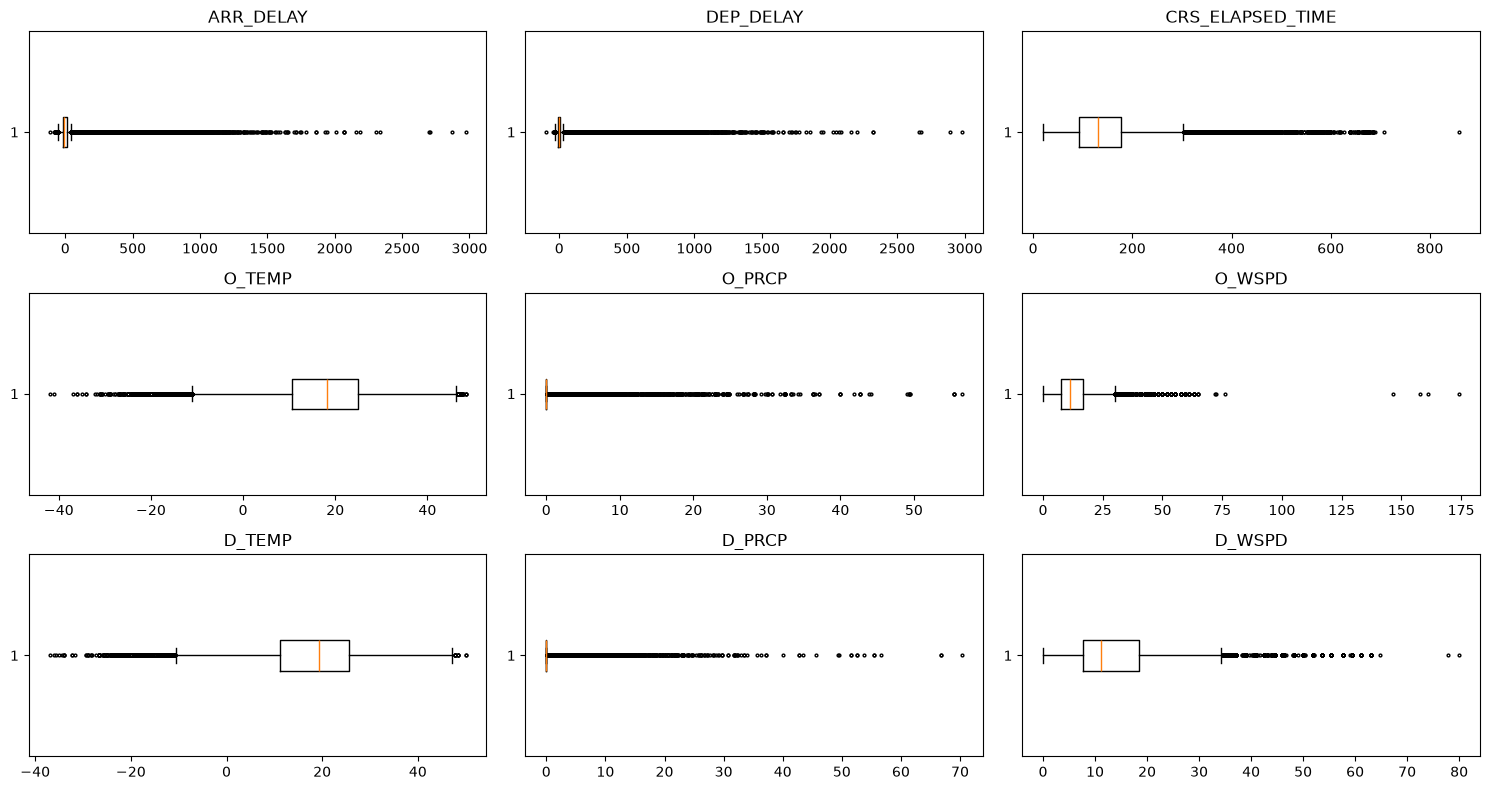

Decision: extreme delays are NOT removed - they are the Severe class we want to predict.
DEP_DELAY is clipped to -30..300 min only when building the recent-delay features (stops one huge value dominating an average).


In [4]:
# 11c. Outliers
cols = ["ARR_DELAY", "DEP_DELAY", "CRS_ELAPSED_TIME", "O_TEMP", "O_PRCP", "O_WSPD", "D_TEMP", "D_PRCP", "D_WSPD"]
rows = []
for c in cols:
    s = df[c].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    rows.append({"column": c, "min": s.min(), "q1": q1, "median": s.median(), "q3": q3, "max": s.max(),
                 "outliers_%(IQR rule)": round(float(((s < lo) | (s > hi)).mean() * 100), 2)})
outlier_table = pd.DataFrame(rows).round(2)
display(outlier_table)
outlier_table.to_csv(EDA_DIR / "outliers.csv", index=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 8))
for a, c in zip(axes.ravel(), cols):
    a.boxplot(eda[c].dropna(), vert=False, flierprops={"markersize": 2})
    a.set_title(c)
fig.tight_layout(); fig.savefig(EDA_DIR / "eda_outliers.png", dpi=150); plt.show()

print("Decision: extreme delays are NOT removed - they are the Severe class we want to predict.")
print("DEP_DELAY is clipped to -30..300 min only when building the recent-delay features (stops one huge value dominating an average).")

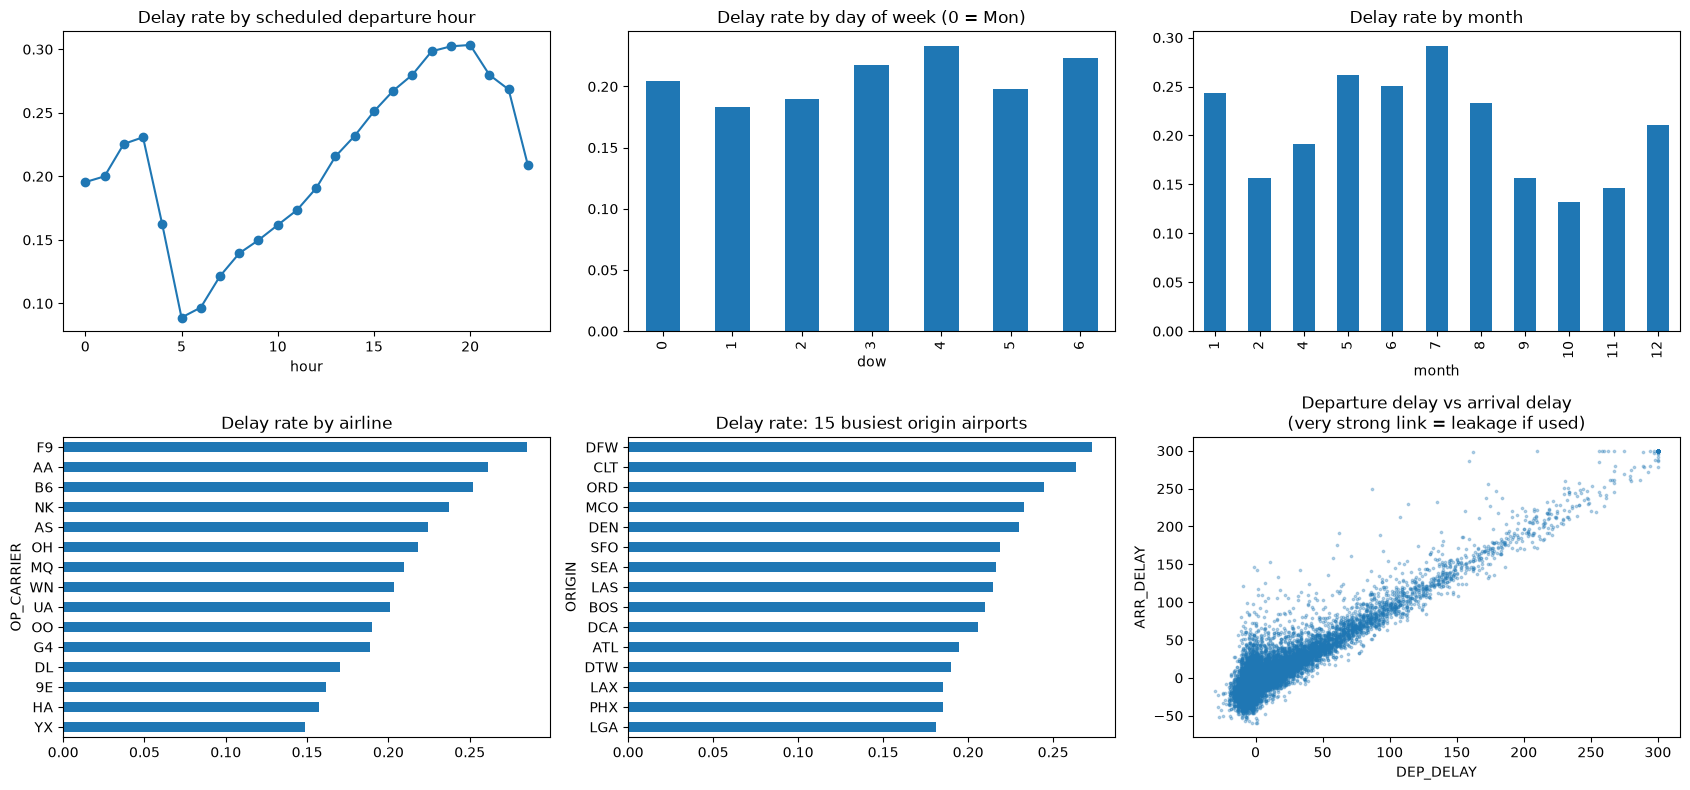

In [5]:
# 11d. Relationships with delay
e = eda.assign(delayed=(eda["ARR_DELAY"] >= 15).astype(float),
               hour=(eda["CRS_DEP_TIME"] // 100),
               dow=eda["FL_DATE"].dt.dayofweek,
               month=eda["FL_DATE"].dt.month)
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
e.groupby("hour")["delayed"].mean().plot(ax=axes[0, 0], marker="o", title="Delay rate by scheduled departure hour")
e.groupby("dow")["delayed"].mean().plot.bar(ax=axes[0, 1], title="Delay rate by day of week (0 = Mon)")
e.groupby("month")["delayed"].mean().plot.bar(ax=axes[0, 2], title="Delay rate by month")
e.groupby("OP_CARRIER")["delayed"].mean().sort_values().plot.barh(ax=axes[1, 0], title="Delay rate by airline")
top = e["ORIGIN"].value_counts().head(15).index
e[e["ORIGIN"].isin(top)].groupby("ORIGIN")["delayed"].mean().sort_values().plot.barh(
    ax=axes[1, 1], title="Delay rate: 15 busiest origin airports")
sc = e.sample(n=min(20_000, len(e)), random_state=SEED)
axes[1, 2].scatter(sc["DEP_DELAY"].clip(-60, 300), sc["ARR_DELAY"].clip(-60, 300), s=3, alpha=0.3)
axes[1, 2].set_title("Departure delay vs arrival delay\n(very strong link = leakage if used)")
axes[1, 2].set_xlabel("DEP_DELAY"); axes[1, 2].set_ylabel("ARR_DELAY")
fig.tight_layout(); fig.savefig(EDA_DIR / "eda_relationships.png", dpi=150); plt.show()

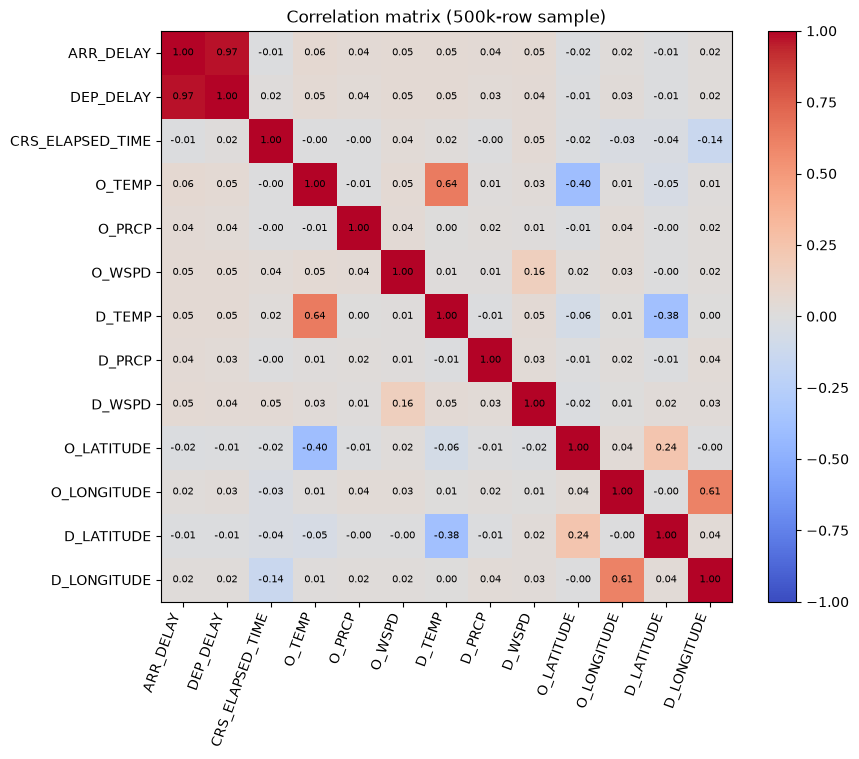

DEP_DELAY           0.971
O_TEMP              0.062
D_TEMP              0.054
O_WSPD              0.053
D_WSPD              0.053
D_PRCP              0.041
O_PRCP              0.040
O_LONGITUDE         0.020
D_LONGITUDE         0.019
O_LATITUDE         -0.019
CRS_ELAPSED_TIME   -0.009
D_LATITUDE         -0.008
Name: ARR_DELAY, dtype: float64


,item,leakage risk,how it is prevented
0,DEP_DELAY,Only known after the plane leaves the gate; co...,Never used as a feature of the flight itself (...
1,"DEP_TIME, WHEELS_OFF, TAXI_OUT, WHEELS_ON, TAX...",Realised during or after the flight,Not loaded at all
2,ARR_DELAY,It is the target,Used only to create the 4 class labels
3,Recent-delay (context) features,Could include the flight itself or future flights,Only flights scheduled >= 3 h earlier are used...
4,Train / validation / test split,A random split lets the model see the future,Time-based split: Jan-Aug / Sep-Oct / Nov-Dec
5,"Encoders, class weights",Fitting them on all data leaks information,Fitted on the training set only
6,Class multipliers,Tuning on test data would inflate scores,Tuned on validation only; test used once at th...


In [6]:
# 11e. Correlation and the data-leakage checklist
num_cols_eda = ["ARR_DELAY", "DEP_DELAY", "CRS_ELAPSED_TIME", "O_TEMP", "O_PRCP", "O_WSPD",
                "D_TEMP", "D_PRCP", "D_WSPD", "O_LATITUDE", "O_LONGITUDE", "D_LATITUDE", "D_LONGITUDE"]
corr = eda[num_cols_eda].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols_eda))); ax.set_xticklabels(num_cols_eda, rotation=70, ha="right")
ax.set_yticks(range(len(num_cols_eda))); ax.set_yticklabels(num_cols_eda)
for i in range(len(num_cols_eda)):
    for j in range(len(num_cols_eda)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im); ax.set_title("Correlation matrix (500k-row sample)")
fig.tight_layout(); fig.savefig(EDA_DIR / "eda_correlation.png", dpi=150); plt.show()

dep_corr = corr.loc["ARR_DELAY", "DEP_DELAY"]
print(corr["ARR_DELAY"].drop("ARR_DELAY").sort_values(key=abs, ascending=False).round(3))

leak = pd.DataFrame([
    ("DEP_DELAY", f"Only known after the plane leaves the gate; correlation with ARR_DELAY = {dep_corr:.2f}",
     "Never used as a feature of the flight itself (only to build lagged context of OTHER flights)"),
    ("DEP_TIME, WHEELS_OFF, TAXI_OUT, WHEELS_ON, TAXI_IN, ARR_TIME, ACTUAL_ELAPSED_TIME, AIR_TIME",
     "Realised during or after the flight", "Not loaded at all"),
    ("ARR_DELAY", "It is the target", "Used only to create the 4 class labels"),
    ("Recent-delay (context) features", "Could include the flight itself or future flights",
     f"Only flights scheduled >= {LAG_H} h earlier are used; the flight is never in its own window"),
    ("Train / validation / test split", "A random split lets the model see the future", "Time-based split: Jan-Aug / Sep-Oct / Nov-Dec"),
    ("Encoders, class weights", "Fitting them on all data leaks information", "Fitted on the training set only"),
    ("Class multipliers", "Tuning on test data would inflate scores", "Tuned on validation only; test used once at the end"),
], columns=["item", "leakage risk", "how it is prevented"])
display(leak)
leak.to_csv(EDA_DIR / "leakage_checklist.csv", index=False)

In [22]:
pip install optuna

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.4 MB 2.7 MB/s eta 0:00:01
   --------------------- ------------------ 1.3/2.4 MB 3.1 MB/s eta 0:00:01
   -------------------------------------- - 2.4/2.4 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 3.7 MB/s  0:00:00

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [sqlalchemy]
   ------ --------------------------------- 1/6 [sqlalchemy]
   ------ --------------------------------- 1/6 [sqlalchemy]
   ------ --------------------------------- 1/6 [sqlalchemy]
   ------ --------------------------------- 1/6 [sqlalchemy]
   ------ --------------------------------- 1/6 [


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Part 3 - Context features (the important new part)
For every flight we look at flights that were **scheduled 3 or more hours before it** and measure how late they were at the same origin airport, the same destination airport and the same airline. We also count how many flights are scheduled at the airport in the same hour (the schedule is known in advance).

Leakage notes: the flight itself is never part of its own window, and its own `ARR_DELAY` / `DEP_DELAY` is never used. The 3-hour lag is an approximation (a flight scheduled 3 hours earlier that is delayed by more than 2 hours would not yet have left); raise `LAG_H` to 4 if you want it stricter.

In [7]:
START = pd.Timestamp("2024-01-01")
LAG_H = 3                 # only use flights scheduled >= 3 hours before this one
WINDOWS = (3, 12)         # look-back windows in hours

airports = pd.Index(pd.unique(pd.concat([df["ORIGIN"], df["DEST"]], ignore_index=True)))
carriers = pd.Index(pd.unique(df["OP_CARRIER"]))


def hour_bin(d):
    """Hours since START for the scheduled departure (-1 if the time is missing)."""
    days = (d["FL_DATE"] - START).dt.days.to_numpy().astype(np.int64)
    t = d["CRS_DEP_TIME"].to_numpy(dtype=float)
    hh = np.floor(t / 100)
    ok = np.isfinite(t) & (hh >= 0) & (hh <= 24)
    return np.where(ok, days * 24 + (np.nan_to_num(hh) % 24), -1).astype(np.int64)


hb_all = hour_bin(df)
H = int(hb_all.max()) + 1
dep_all = np.clip(df["DEP_DELAY"].to_numpy(dtype=float), -30, 300)


def build_cum(codes, n_ent):
    """Cumulative (count, sum of dep delay, count of dep delay >= 15) per entity per hour."""
    ok = (hb_all >= 0) & np.isfinite(dep_all) & (codes >= 0)
    flat = codes[ok].astype(np.int64) * H + hb_all[ok]
    d = dep_all[ok]
    size = n_ent * H
    arrays = [np.bincount(flat, minlength=size),
              np.bincount(flat, weights=d, minlength=size),
              np.bincount(flat, weights=(d >= 15).astype(float), minlength=size)]
    out = []
    for a in arrays:
        a = a.reshape(n_ent, H).astype(np.float64)
        out.append(np.concatenate([np.zeros((n_ent, 1)), np.cumsum(a, axis=1)], axis=1))
    return out


apt_cum = build_cum(airports.get_indexer(df["ORIGIN"]), len(airports))
car_cum = build_cum(carriers.get_indexer(df["OP_CARRIER"]), len(carriers))


def window_stats(cum, codes, hb, lag, win):
    cn, cs, cl = cum
    hi = np.clip(hb - lag + 1, 0, H)
    lo = np.clip(hb - lag - win + 1, 0, H)
    c = np.where(codes >= 0, codes, 0)
    n = cn[c, hi] - cn[c, lo]
    s = cs[c, hi] - cs[c, lo]
    l = cl[c, hi] - cl[c, lo]
    bad = (hb < 0) | (codes < 0) | (n < 1)
    mean = np.where(bad, np.nan, s / np.maximum(n, 1))
    rate = np.where(bad, np.nan, l / np.maximum(n, 1))
    return mean.astype(np.float32), rate.astype(np.float32), n.astype(np.float32)


def context_features(d):
    hb = hour_bin(d)
    o = airports.get_indexer(d["ORIGIN"])
    de = airports.get_indexer(d["DEST"])
    c = carriers.get_indexer(d["OP_CARRIER"])
    out = {}
    for prefix, cum, codes in [("o", apt_cum, o), ("d", apt_cum, de), ("c", car_cum, c)]:
        for w in WINDOWS:
            m, r, n = window_stats(cum, codes, hb, LAG_H, w)
            out[f"{prefix}_delay_mean_{w}h"] = m
            out[f"{prefix}_late_rate_{w}h"] = r
            if w == WINDOWS[0]:
                out[f"{prefix}_n_{w}h"] = n
    b = np.clip(hb, 0, H - 1)
    for prefix, codes in [("o", o), ("d", de)]:      # scheduled departures in the same hour
        cc = np.where(codes >= 0, codes, 0)
        cn = apt_cum[0]
        out[f"{prefix}_sched_n_same_hour"] = np.where(
            hb >= 0, cn[cc, b + 1] - cn[cc, b], np.nan).astype(np.float32)
    return pd.DataFrame(out, index=d.index)


print("Airports:", len(airports), "| carriers:", len(carriers), "| hours in year:", H)
print(context_features(df.head(3)).T)

Airports: 306 | carriers: 15 | hours in year: 8784
                             0          1     2
o_delay_mean_3h       1.597015   0.828571   NaN
o_late_rate_3h        0.104478   0.114286   NaN
o_n_3h               67.000000  35.000000   0.0
o_delay_mean_12h      1.341463   1.437086   NaN
o_late_rate_12h       0.097561   0.099338   NaN
d_delay_mean_3h       4.163265   5.742857   NaN
d_late_rate_3h        0.102041   0.114286   NaN
d_n_3h               49.000000  35.000000   0.0
d_delay_mean_12h      2.265625   1.671329   NaN
d_late_rate_12h       0.078125   0.062937   NaN
c_delay_mean_3h       2.079365  -3.725275   NaN
c_late_rate_3h        0.095238   0.043956   NaN
c_n_3h               63.000000  91.000000   0.0
c_delay_mean_12h      0.336634  -2.082353   NaN
c_late_rate_12h       0.079208   0.062745   NaN
o_sched_n_same_hour  13.000000  20.000000  23.0
d_sched_n_same_hour  21.000000   9.000000   7.0


## Part 4 - Time split, sampling, features and labels

In [8]:
CAT_COLS = ["OP_CARRIER", "ORIGIN", "DEST"]


def make_features(data):
    """Same function for train / validation / test. DEP_DELAY and ARR_DELAY are dropped here."""
    X = data.drop(columns=["FL_DATE", "ARR_DELAY", "DEP_DELAY"], errors="ignore").copy()
    dates = pd.to_datetime(data["FL_DATE"], errors="coerce")

    X = X.drop(columns=["MONTH", "DAY_OF_MONTH", "DAY_OF_WEEK"], errors="ignore")
    X["month"] = dates.dt.month
    X["day_of_month"] = dates.dt.day
    X["day_of_week"] = dates.dt.dayofweek
    X["month_sin"] = np.sin(2 * np.pi * X["month"] / 12)
    X["month_cos"] = np.cos(2 * np.pi * X["month"] / 12)

    for col in ["CRS_DEP_TIME", "CRS_ARR_TIME"]:          # HHMM -> hour / minute / cyclic
        values = pd.to_numeric(X[col], errors="coerce")
        hours = np.floor(values / 100)
        minutes = values % 100
        valid = ((values == np.floor(values))
                 & ((hours.between(0, 23) & minutes.between(0, 59)) | (values == 2400)))
        hour = (hours % 24).where(valid)
        minute = minutes.where(valid)
        X[f"{col}_hour"] = hour
        X[f"{col}_minute"] = minute
        mod = hour * 60 + minute
        X[f"{col}_sin"] = np.sin(2 * np.pi * mod / 1440)
        X[f"{col}_cos"] = np.cos(2 * np.pi * mod / 1440)
    X = X.drop(columns=["CRS_DEP_TIME", "CRS_ARR_TIME"])

    coord_cols = ["O_LATITUDE", "O_LONGITUDE", "D_LATITUDE", "D_LONGITUDE"]
    lat1, lon1, lat2, lon2 = [np.radians(pd.to_numeric(X[c], errors="coerce")) for c in coord_cols]
    h = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    X["distance_km"] = 6371 * 2 * np.arcsin(np.sqrt(np.clip(h, 0, 1)))
    X = X.drop(columns=coord_cols)

    X = pd.concat([X, context_features(data)], axis=1)     # <-- new context features

    for col in CAT_COLS:
        X[col] = X[col].astype("string").fillna("__MISSING__").astype(str)
    numerical = X.columns.difference(CAT_COLS)
    X[numerical] = X[numerical].replace([np.inf, -np.inf], np.nan)
    return X


def make_labels(data):
    return np.digitize(data["ARR_DELAY"].to_numpy(), bins=BINS).astype(np.int64)


def sample_rows(data, limit):
    if limit is None or len(data) <= limit:
        return data.copy()
    return data.sample(n=limit, random_state=SEED).sort_values("FL_DATE").copy()


train_df = df[df["FL_DATE"] <= TRAIN_END]
val_df = df[(df["FL_DATE"] > TRAIN_END) & (df["FL_DATE"] <= VAL_END)]
test_df = df[df["FL_DATE"] > VAL_END]

for name, part in [("Training", train_df), ("Validation", val_df), ("Test", test_df)]:
    if part.empty:
        raise ValueError(f"{name} is empty. Check the dates in Part 1.")
    print(f"{name}: {len(part):,} rows | {part['FL_DATE'].min().date()} to {part['FL_DATE'].max().date()}")

train_df = sample_rows(train_df, TRAIN_LIMIT)
val_df = sample_rows(val_df, VAL_LIMIT)

X_train_raw, X_val_raw = make_features(train_df), make_features(val_df)
y_train, y_val = make_labels(train_df), make_labels(val_df)

for name, target in [("Training", y_train), ("Validation", y_val)]:
    counts = np.bincount(target, minlength=4)
    print(f"\n{name} class share:")
    print((pd.Series(counts, index=CLASS_NAMES) / counts.sum()).round(3))
    if (counts == 0).any():
        raise ValueError(f"{name} is missing a class.")

print("\nNumber of features:", X_train_raw.shape[1])
print("\nSANITY CHECK - share of missing values (must be small, NOT 1.0):")
print(X_train_raw[["CRS_DEP_TIME_hour", "o_delay_mean_3h", "d_delay_mean_3h", "c_delay_mean_3h"]].isna().mean().round(3))

Training: 3,975,694 rows | 2024-01-01 to 2024-08-31
Validation: 1,171,417 rows | 2024-09-01 to 2024-10-31
Test: 1,137,730 rows | 2024-11-01 to 2024-12-31

Training class share:
On-time     0.764
Minor       0.121
Moderate    0.079
Severe      0.036
dtype: float64

Validation class share:
On-time     0.855
Minor       0.087
Moderate    0.043
Severe      0.015
dtype: float64

Number of features: 41

SANITY CHECK - share of missing values (must be small, NOT 1.0):
CRS_DEP_TIME_hour    0.000
o_delay_mean_3h      0.177
d_delay_mean_3h      0.177
c_delay_mean_3h      0.106
dtype: float64


## Part 5 - Encode the categorical columns

In [9]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=np.float32)
encoder.fit(X_train_raw[CAT_COLS])
FEATURE_COLS = X_train_raw.columns.tolist()


def encode_features(raw):
    X = raw.reindex(columns=FEATURE_COLS).copy()
    X[CAT_COLS] = encoder.transform(X[CAT_COLS])
    return X.astype(np.float32)


X_train, X_val = encode_features(X_train_raw), encode_features(X_val_raw)
print("Training:", X_train.shape, "| Validation:", X_val.shape)

Training: (100000, 41) | Validation: (30000, 41)


## Part 6 - Train the 4 models
Class weights come from the training set. The **validation set gets the same weights**, so early stopping judges the models the same way they are trained. Check the `best_iter` column in Part 7: if it is tiny (below about 20) the model is still not learning much.

In [10]:
counts = np.bincount(y_train, minlength=4)
class_w = len(y_train) / (4 * counts)          # "balanced" weights, from TRAIN only
w_train, w_val = class_w[y_train], class_w[y_val]

N_TREES = 150 if QUICK else 2000
PATIENCE = 30 if QUICK else 100

models, train_seconds, best_iters = {}, {}, {}


def timed(name, fn):
    print(f"Training {name}...", flush=True)
    t0 = time.time()
    models[name] = fn()
    train_seconds[name] = time.time() - t0
    print(f"  done in {train_seconds[name]:.1f}s", flush=True)


def fit_lgb():
    m = LGBMClassifier(objective="multiclass", num_class=4, n_estimators=N_TREES, learning_rate=0.05,
                       num_leaves=127, min_child_samples=100, subsample=0.8, subsample_freq=1,
                       colsample_bytree=0.8, reg_lambda=1.0, n_jobs=-1, random_state=SEED, verbosity=-1)
    m.fit(X_train, y_train, sample_weight=w_train,
          eval_set=[(X_val, y_val)], eval_sample_weight=[w_val],
          callbacks=[early_stopping(PATIENCE, verbose=False)])
    best_iters["LightGBM"] = m.best_iteration_
    return m


def fit_xgb():
    m = XGBClassifier(objective="multi:softprob", num_class=4, n_estimators=N_TREES, learning_rate=0.08,
                      max_depth=8, subsample=0.8, colsample_bytree=0.8, tree_method="hist",
                      eval_metric="mlogloss", early_stopping_rounds=PATIENCE, n_jobs=-1, random_state=SEED)
    m.fit(X_train, y_train, sample_weight=w_train,
          eval_set=[(X_val, y_val)], sample_weight_eval_set=[w_val], verbose=False)
    best_iters["XGBoost"] = m.best_iteration
    return m


def fit_cat():
    m = CatBoostClassifier(loss_function="MultiClass", iterations=N_TREES, learning_rate=0.08, depth=8,
                           early_stopping_rounds=PATIENCE, random_seed=SEED, thread_count=-1,
                           verbose=False, allow_writing_files=False)
    m.fit(X_train, y_train, sample_weight=w_train, eval_set=Pool(X_val, y_val, weight=w_val))
    best_iters["CatBoost"] = m.get_best_iteration()
    return m


rf_idx = np.random.default_rng(SEED).choice(len(X_train), size=min(RF_LIMIT, len(X_train)), replace=False)


def fit_rf():
    m = RandomForestClassifier(n_estimators=60 if QUICK else 300, min_samples_leaf=20, max_features="sqrt",
                               class_weight="balanced_subsample", n_jobs=-1, random_state=SEED)
    m.fit(X_train.iloc[rf_idx].fillna(-999), y_train[rf_idx])
    best_iters["RandomForest"] = m.n_estimators
    return m


timed("LightGBM", fit_lgb)
timed("XGBoost", fit_xgb)
timed("CatBoost", fit_cat)
timed("RandomForest", fit_rf)

Training LightGBM...


  done in 6.0s
Training XGBoost...
  done in 18.1s
Training CatBoost...
  done in 20.1s
Training RandomForest...
  done in 1.2s


## Part 7 - Compare on validation and select 1 model
Selection rule: highest **validation macro-F1 after tuning the class multipliers**. The test set is not touched here.

In [11]:
def get_proba(name, model, X):
    if name == "RandomForest":
        X = X.fillna(-999)
    proba = model.predict_proba(X)
    if not np.array_equal(model.classes_, LABELS):
        raise ValueError(f"{name}: unexpected class order {model.classes_}")
    return proba


def macro_f1_fast(y, pred):
    cm = np.bincount(y * 4 + pred, minlength=16).reshape(4, 4)
    tp = np.diag(cm)
    den = cm.sum(axis=0) + cm.sum(axis=1)
    return np.divide(2 * tp, den, out=np.zeros(4), where=den != 0).mean()


def tune_multipliers(proba, y):
    w = np.ones(4)
    best = macro_f1_fast(y, proba.argmax(1))
    grid = np.geomspace(0.25, 8, 28)                  # wide, log-spaced search
    for _ in range(3):
        for c in [1, 2, 3]:
            for g in grid:
                trial = w.copy()
                trial[c] = g
                s = macro_f1_fast(y, (proba * trial).argmax(1))
                if s > best:
                    best, w = s, trial
    return w, best


rows, multipliers = [], {}
for name, model in models.items():
    p = get_proba(name, model, X_val)
    w, tuned = tune_multipliers(p, y_val)
    multipliers[name] = w
    pred0, pred1 = p.argmax(1), (p * w).argmax(1)
    rows.append({"model": name, "train_sec": round(train_seconds[name], 1), "best_iter": best_iters[name],
                 "val_acc": accuracy_score(y_val, pred0),
                 "val_macro_f1": f1_score(y_val, pred0, labels=LABELS, average="macro", zero_division=0),
                 "val_macro_f1_tuned": tuned,
                 "val_acc_tuned": accuracy_score(y_val, pred1),
                 "val_macro_prec_tuned": precision_score(y_val, pred1, labels=LABELS, average="macro", zero_division=0),
                 "val_macro_rec_tuned": recall_score(y_val, pred1, labels=LABELS, average="macro", zero_division=0)})

baseline = np.zeros(len(y_val), dtype=int)               # always predict On-time
rows.append({"model": "BASELINE always On-time", "val_acc": accuracy_score(y_val, baseline),
             "val_macro_f1": macro_f1_fast(y_val, baseline), "val_macro_f1_tuned": macro_f1_fast(y_val, baseline)})

comparison = pd.DataFrame(rows).sort_values("val_macro_f1_tuned", ascending=False).reset_index(drop=True)
comparison.to_csv(OUTPUT_DIR / "model_comparison_validation.csv", index=False)
display(comparison.round(4))

best_name = comparison[comparison["model"].isin(models)].iloc[0]["model"]
best_model, best_multipliers = models[best_name], multipliers[best_name]
print("\nSelected model:", best_name)
print("Class multipliers:", np.round(best_multipliers, 2))

,model,train_sec,best_iter,val_acc,val_macro_f1,val_macro_f1_tuned,val_acc_tuned,val_macro_prec_tuned,val_macro_rec_tuned
0,XGBoost,18.1,51.0,0.7681,0.2972,0.3071,0.7505,0.3025,0.3183
1,LightGBM,6.0,45.0,0.7568,0.3046,0.3066,0.7703,0.3062,0.3138
2,CatBoost,20.1,87.0,0.7553,0.3033,0.3050,0.7538,0.3045,0.3095
3,RandomForest,1.2,60.0,0.7934,0.2924,0.2999,0.7796,0.3018,0.3004
4,BASELINE always On-time,NaN,NaN,0.8548,0.2304,0.2304,NaN,NaN,NaN



Selected model: XGBoost
Class multipliers: [1.   1.03 1.17 1.33]


## Part 8 - Which features matter? (check that the context features help)

In [12]:
imp = pd.Series(models["LightGBM"].booster_.feature_importance("gain"), index=FEATURE_COLS)
imp = (imp / imp.sum()).sort_values(ascending=False)
display(imp.head(20).round(4).to_frame("share_of_gain"))
ctx_share = imp[[c for c in imp.index if c[:2] in ("o_", "d_", "c_")]].sum()
print(f"Share of importance from context features: {ctx_share:.1%}")

,share_of_gain
c_delay_mean_3h,0.1317
o_delay_mean_3h,0.0763
c_late_rate_3h,0.0419
d_delay_mean_3h,0.0411
o_delay_mean_12h,0.0337
c_delay_mean_12h,0.0333
d_delay_mean_12h,0.0311
c_n_3h,0.0290
CRS_DEP_TIME_cos,0.0277
distance_km,0.0276


Share of importance from context features: 62.3%


## Part 9 - Final TEST evaluation (run once, only when `QUICK = False`)
Uses the model selected in Part 7 and the multipliers tuned on validation. Do not go back and tune after seeing these numbers.

In [19]:
if QUICK:
    print("QUICK mode: skipping TEST. Set QUICK = False in Part 1 and run everything again.")
else:
    X_test = encode_features(make_features(test_df))          # full test period (Nov-Dec)
    y_test = make_labels(test_df)

    proba_test = get_proba(best_name, best_model, X_test)
    pred = (proba_test * best_multipliers).argmax(1)

    results = {
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, labels=LABELS, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, pred, labels=LABELS, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_test, pred, labels=LABELS, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, pred, labels=LABELS, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_test, pred),
        "baseline_macro_f1_always_ontime": macro_f1_fast(y_test, np.zeros(len(y_test), dtype=int)),
    }
    print("Selected model:", best_name)
    for k, v in results.items():
        print(f"{k:34s}: {v:.4f}")

    report = classification_report(y_test, pred, labels=LABELS, target_names=CLASS_NAMES, digits=4, zero_division=0)
    print("\n" + report)

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred, labels=LABELS, normalize="true"),
                           display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", values_format=".2f")
    ax.set_title(f"{best_name} - test confusion matrix (row-normalised)")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "confusion_matrix_test.png", dpi=150)
    plt.show()

    with open(OUTPUT_DIR / "test_report.txt", "w") as f:
        f.write(f"Selected: {best_name}\n{pd.Series(results).to_string()}\n\n{report}")
    joblib.dump({"model": best_model, "name": best_name, "multipliers": best_multipliers,
                 "features": FEATURE_COLS, "encoder": encoder}, OUTPUT_DIR / "best_model.joblib")
    print("Saved to:", OUTPUT_DIR)

QUICK mode: skipping TEST. Set QUICK = False in Part 1 and run everything again.


## Part 12 - Baseline models (with imputing and scaling)
Baselines show what a model must beat. Logistic regression needs scaled numbers, so it is the place where scaling is actually required (tree models do not need it).

In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


def val_metrics(name, proba=None, pred=None, y=None):
    y = y_val if y is None else y
    if proba is not None:
        w, tuned = tune_multipliers(proba, y)
        pred0, pred1 = proba.argmax(1), (proba * w).argmax(1)
    else:
        pred0 = pred1 = pred
        tuned = macro_f1_fast(y, pred)
    return {"model": name,
            "val_acc": accuracy_score(y, pred0),
            "val_macro_f1": f1_score(y, pred0, labels=LABELS, average="macro", zero_division=0),
            "val_macro_f1_tuned": tuned,
            "val_acc_tuned": accuracy_score(y, pred1),
            "val_macro_prec_tuned": precision_score(y, pred1, labels=LABELS, average="macro", zero_division=0),
            "val_macro_rec_tuned": recall_score(y, pred1, labels=LABELS, average="macro", zero_division=0)}


baseline_rows = []

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline_rows.append(val_metrics("Baseline: always On-time", pred=dummy.predict(X_val)))

num_cols = [c for c in FEATURE_COLS if c not in CAT_COLS]      # ORIGIN / DEST codes are meaningless as numbers
lr_pipe = Pipeline([
    ("prep", ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_cols),
        ("carrier", OneHotEncoder(handle_unknown="ignore"), ["OP_CARRIER"])])),
    ("clf", LogisticRegression(max_iter=300, class_weight="balanced"))])

t0 = time.time()
idx = np.random.default_rng(SEED).choice(len(X_train), min(200_000, len(X_train)), replace=False)
lr_pipe.fit(X_train.iloc[idx], y_train[idx])
print(f"Logistic regression trained in {time.time() - t0:.0f}s")
baseline_rows.append(val_metrics("Baseline: Logistic Regression (scaled)", proba=lr_pipe.predict_proba(X_val)))

baseline_table = pd.DataFrame(baseline_rows)
all_models_table = (pd.concat([baseline_table,
                               comparison[comparison["model"].isin(models)].drop(columns=["train_sec", "best_iter"], errors="ignore")],
                              ignore_index=True)
                    .sort_values("val_macro_f1_tuned", ascending=False).reset_index(drop=True))
display(all_models_table.round(4))
all_models_table.to_csv(OUTPUT_DIR / "all_models_validation.csv", index=False)

Logistic regression trained in 4s


,model,val_acc,val_macro_f1,val_macro_f1_tuned,val_acc_tuned,val_macro_prec_tuned,val_macro_rec_tuned
0,XGBoost,0.7681,0.2972,0.3071,0.7505,0.3025,0.3183
1,LightGBM,0.7568,0.3046,0.3066,0.7703,0.3062,0.3138
2,CatBoost,0.7553,0.3033,0.3050,0.7538,0.3045,0.3095
3,Baseline: Logistic Regression (scaled),0.7845,0.2848,0.3024,0.7509,0.2999,0.3075
4,RandomForest,0.7934,0.2924,0.2999,0.7796,0.3018,0.3004
5,Baseline: always On-time,0.8548,0.2304,0.2304,0.8548,0.2137,0.2500


## Part 13 - Hyperparameter tuning with Optuna (Stage 7)
Optuna uses Bayesian optimisation (TPE): each new trial is chosen using the results of earlier trials, which is more efficient than a blind grid or random search. The score being maximised is **validation macro-F1 after class-multiplier tuning**. Tuning uses a subsample for speed; the best settings are then refit on the full training sample in the next cell.

Install once if needed: `pip install optuna` (run it in a terminal or as `%pip install optuna` in a cell).

LightGBM: 20 trials in 181s | best subsample score = 0.3134
   best params: {'learning_rate': 0.0425, 'num_leaves': 230, 'min_child_samples': 178, 'subsample': 0.7993, 'colsample_bytree': 0.4936, 'reg_lambda': 0.005, 'reg_alpha': 0.0017}
XGBoost: 20 trials in 535s | best subsample score = 0.3175
   best params: {'learning_rate': 0.0289, 'max_depth': 6, 'min_child_weight': 1.6004, 'subsample': 0.5761, 'colsample_bytree': 0.4455, 'reg_lambda': 0.1918, 'reg_alpha': 0.6014, 'gamma': 0.0743}


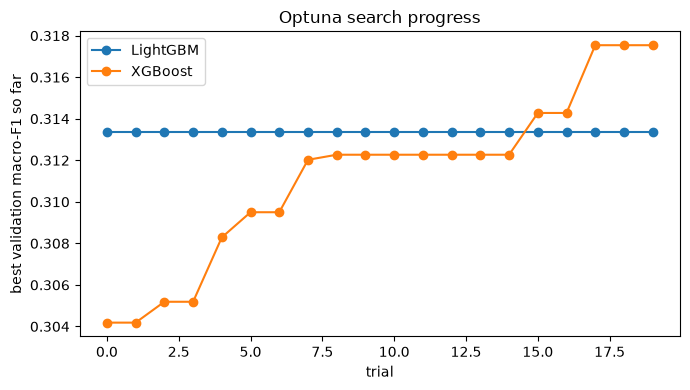

In [14]:
import json
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 20                 # trials per model
TUNE_TIMEOUT_SEC = 900        # stop a model's search after 15 minutes at most
TUNE_TRAIN, TUNE_VAL = 200_000, 100_000
N_FINAL_TREES = 300 if QUICK else 2000

rs = np.random.default_rng(SEED)
ti = rs.choice(len(X_train), min(TUNE_TRAIN, len(X_train)), replace=False)
vi = rs.choice(len(X_val), min(TUNE_VAL, len(X_val)), replace=False)
Xt, yt, wt = X_train.iloc[ti], y_train[ti], w_train[ti]
Xv, yv, wv = X_val.iloc[vi], y_val[vi], w_val[vi]


def obj_lgb(trial):
    p = dict(learning_rate=trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
             num_leaves=trial.suggest_int("num_leaves", 31, 255, log=True),
             min_child_samples=trial.suggest_int("min_child_samples", 20, 400, log=True),
             subsample=trial.suggest_float("subsample", 0.5, 1.0),
             colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
             reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 30, log=True),
             reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True))
    m = LGBMClassifier(objective="multiclass", num_class=4, n_estimators=1000, subsample_freq=1,
                       n_jobs=-1, random_state=SEED, verbosity=-1, **p)
    m.fit(Xt, yt, sample_weight=wt, eval_set=[(Xv, yv)], eval_sample_weight=[wv],
          callbacks=[early_stopping(50, verbose=False)])
    _, score = tune_multipliers(m.predict_proba(Xv), yv)
    trial.set_user_attr("best_iter", int(m.best_iteration_))
    return score


def obj_xgb(trial):
    p = dict(learning_rate=trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
             max_depth=trial.suggest_int("max_depth", 4, 10),
             min_child_weight=trial.suggest_float("min_child_weight", 1, 50, log=True),
             subsample=trial.suggest_float("subsample", 0.5, 1.0),
             colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
             reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 30, log=True),
             reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
             gamma=trial.suggest_float("gamma", 1e-3, 5, log=True))
    m = XGBClassifier(objective="multi:softprob", num_class=4, n_estimators=1000, tree_method="hist",
                      eval_metric="mlogloss", early_stopping_rounds=50, n_jobs=-1, random_state=SEED, **p)
    m.fit(Xt, yt, sample_weight=wt, eval_set=[(Xv, yv)], sample_weight_eval_set=[wv], verbose=False)
    _, score = tune_multipliers(m.predict_proba(Xv), yv)
    trial.set_user_attr("best_iter", int(m.best_iteration))
    return score


studies = {}
for name, objective in [("LightGBM", obj_lgb), ("XGBoost", obj_xgb)]:
    t0 = time.time()
    st = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    st.optimize(objective, n_trials=N_TRIALS, timeout=TUNE_TIMEOUT_SEC)
    studies[name] = st
    st.trials_dataframe().to_csv(OUTPUT_DIR / f"tuning_trials_{name}.csv", index=False)
    print(f"{name}: {len(st.trials)} trials in {time.time() - t0:.0f}s | best subsample score = {st.best_value:.4f}")
    print("   best params:", {k: round(v, 4) if isinstance(v, float) else v for k, v in st.best_params.items()})

fig, ax = plt.subplots(figsize=(7, 4))
for name, st in studies.items():
    vals = [t.value for t in st.trials]
    ax.plot(np.maximum.accumulate(vals), marker="o", label=name)
ax.set_xlabel("trial"); ax.set_ylabel("best validation macro-F1 so far"); ax.legend(); ax.set_title("Optuna search progress")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "tuning_progress.png", dpi=150); plt.show()

with open(OUTPUT_DIR / "tuning_best_params.json", "w") as f:
    json.dump({k: v.best_params for k, v in studies.items()}, f, indent=2)

In [15]:
# Refit the best settings on the FULL training sample and compare with the untuned models from Part 7
def fit_lgb_with(params, cols):
    m = LGBMClassifier(objective="multiclass", num_class=4, n_estimators=N_FINAL_TREES, subsample_freq=1,
                       n_jobs=-1, random_state=SEED, verbosity=-1, **params)
    m.fit(X_train[cols], y_train, sample_weight=w_train, eval_set=[(X_val[cols], y_val)],
          eval_sample_weight=[w_val], callbacks=[early_stopping(100, verbose=False)])
    return m


def fit_xgb_with(params, cols):
    m = XGBClassifier(objective="multi:softprob", num_class=4, n_estimators=N_FINAL_TREES, tree_method="hist",
                      eval_metric="mlogloss", early_stopping_rounds=100, n_jobs=-1, random_state=SEED, **params)
    m.fit(X_train[cols], y_train, sample_weight=w_train, eval_set=[(X_val[cols], y_val)],
          sample_weight_eval_set=[w_val], verbose=False)
    return m


FITTERS = {"LightGBM": fit_lgb_with, "XGBoost": fit_xgb_with}
tuned_models, tuned_mult, tuning_rows = {}, {}, []
for name, st in studies.items():
    t0 = time.time()
    m = FITTERS[name](st.best_params, FEATURE_COLS)
    p = m.predict_proba(X_val[FEATURE_COLS])
    w, _ = tune_multipliers(p, y_val)
    tuned_models[name], tuned_mult[name] = m, w
    row = val_metrics(f"{name} (tuned)", proba=p)
    row["train_sec"] = round(time.time() - t0, 1)
    tuning_rows.append(row)

tuning_table = pd.DataFrame(tuning_rows)
before = comparison.set_index("model")["val_macro_f1_tuned"]
tuning_table["untuned_val_macro_f1"] = [before.get(n.replace(" (tuned)", ""), np.nan) for n in tuning_table["model"]]
tuning_table["gain"] = tuning_table["val_macro_f1_tuned"] - tuning_table["untuned_val_macro_f1"]
display(tuning_table.round(4))
tuning_table.to_csv(OUTPUT_DIR / "tuning_before_after.csv", index=False)

,model,val_acc,val_macro_f1,val_macro_f1_tuned,val_acc_tuned,val_macro_prec_tuned,val_macro_rec_tuned,train_sec,untuned_val_macro_f1,gain
0,LightGBM (tuned),0.7652,0.2981,0.3058,0.7459,0.3012,0.3171,18.9,0.3066,-0.0009
1,XGBoost (tuned),0.7605,0.3073,0.3073,0.7605,0.3107,0.3097,23.7,0.3071,0.0002


## Part 14 - Feature engineering / selection study (Stage 7)
Each feature group is removed in turn and the model is re-trained (same settings, same data subsample). A group whose removal lowers the score is useful. Then a smaller feature set (features with at least 0.5% of the importance) is tested; the smaller set is kept only if it loses almost nothing.

,experiment,n_features,val_macro_f1_tuned,change_vs_all
0,ALL features,41,0.3134,0.0000
1,without recent-delay + traffic (context),24,0.2795,-0.0339
2,without weather,35,0.3050,-0.0084
3,without time of day,33,0.3049,-0.0085
4,without calendar,36,0.3102,-0.0032
5,without airline / airport ids,38,0.3056,-0.0078
6,without distance + duration,39,0.3078,-0.0056
7,SELECTED (importance >= 0.5%),37,0.3090,-0.0043


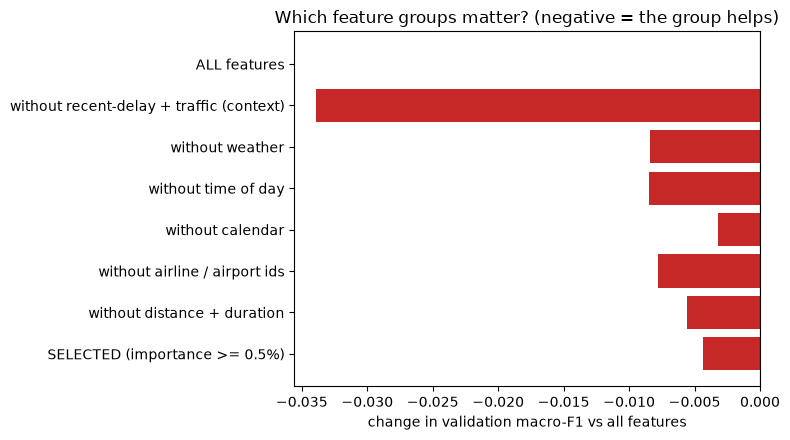

All: 0.3134 | Selected (37 features): 0.3090
FINAL feature set: ALL features (41 features)


In [16]:
base_params = dict(studies["LightGBM"].best_params) if "studies" in globals() and "LightGBM" in studies else \
    dict(learning_rate=0.08, num_leaves=63, min_child_samples=100, subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0)

groups = {
    "recent-delay + traffic (context)": [c for c in FEATURE_COLS if c[:2] in ("o_", "d_", "c_")],
    "weather": ["O_TEMP", "O_PRCP", "O_WSPD", "D_TEMP", "D_PRCP", "D_WSPD"],
    "time of day": [c for c in FEATURE_COLS if c.startswith("CRS_DEP_TIME_") or c.startswith("CRS_ARR_TIME_")],
    "calendar": ["month", "day_of_month", "day_of_week", "month_sin", "month_cos"],
    "airline / airport ids": ["OP_CARRIER", "ORIGIN", "DEST"],
    "distance + duration": ["distance_km", "CRS_ELAPSED_TIME"],
}
groups = {k: [c for c in v if c in FEATURE_COLS] for k, v in groups.items()}


def quick_score(cols):
    m = LGBMClassifier(objective="multiclass", num_class=4, n_estimators=600, subsample_freq=1,
                       n_jobs=-1, random_state=SEED, verbosity=-1, **base_params)
    m.fit(Xt[cols], yt, sample_weight=wt, eval_set=[(Xv[cols], yv)], eval_sample_weight=[wv],
          callbacks=[early_stopping(50, verbose=False)])
    _, s = tune_multipliers(m.predict_proba(Xv[cols]), yv)
    return s


imp = pd.Series(models["LightGBM"].booster_.feature_importance("gain"), index=FEATURE_COLS)
imp = imp / imp.sum()
selected = [c for c in FEATURE_COLS if imp[c] >= 0.005]
if len(selected) < 15:
    selected = imp.sort_values(ascending=False).index[:15].tolist()

rows = [{"experiment": "ALL features", "n_features": len(FEATURE_COLS), "val_macro_f1_tuned": quick_score(FEATURE_COLS)}]
for gname, gcols in groups.items():
    keep = [c for c in FEATURE_COLS if c not in gcols]
    rows.append({"experiment": f"without {gname}", "n_features": len(keep), "val_macro_f1_tuned": quick_score(keep)})
rows.append({"experiment": "SELECTED (importance >= 0.5%)", "n_features": len(selected), "val_macro_f1_tuned": quick_score(selected)})

ablation = pd.DataFrame(rows)
ablation["change_vs_all"] = ablation["val_macro_f1_tuned"] - ablation.loc[0, "val_macro_f1_tuned"]
display(ablation.round(4))
ablation.to_csv(OUTPUT_DIR / "feature_ablation.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(ablation["experiment"][::-1], ablation["change_vs_all"][::-1],
        color=["#c62828" if v < 0 else "#2e8b57" for v in ablation["change_vs_all"][::-1]])
ax.axvline(0, color="black", lw=0.8); ax.set_xlabel("change in validation macro-F1 vs all features")
ax.set_title("Which feature groups matter? (negative = the group helps)")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "feature_ablation.png", dpi=150); plt.show()

score_all, score_sel = ablation.loc[0, "val_macro_f1_tuned"], ablation.iloc[-1]["val_macro_f1_tuned"]
FINAL_FEATURES = selected if score_sel >= score_all - 0.001 else list(FEATURE_COLS)
print(f"All: {score_all:.4f} | Selected ({len(selected)} features): {score_sel:.4f}")
print("FINAL feature set:", "SELECTED subset" if FINAL_FEATURES is selected else "ALL features", f"({len(FINAL_FEATURES)} features)")

## Part 15 - Final model selection and the final test evaluation
Candidates: the tuned LightGBM, the tuned XGBoost (both with the final feature set) and the best untuned model from Part 7. The winner is the highest **validation** macro-F1.
The test set is evaluated for the winner only. Do not change anything after looking at the test numbers.

LightGBM (tuned, 41 features): val macro-F1 0.3058  [14s]
XGBoost (tuned, 41 features): val macro-F1 0.3073  [22s]


,model,val_acc,val_macro_f1,val_macro_f1_tuned,n_features
0,XGBoost (tuned),NaN,NaN,0.3073,41.0
1,XGBoost,0.7681,0.2972,0.3071,NaN
2,LightGBM,0.7568,0.3046,0.3066,NaN
3,LightGBM (tuned),NaN,NaN,0.3058,41.0
4,CatBoost,0.7553,0.3033,0.3050,NaN
5,Baseline: Logistic Regression (scaled),0.7845,0.2848,0.3024,NaN
6,RandomForest,0.7934,0.2924,0.2999,NaN
7,Baseline: always On-time,0.8548,0.2304,0.2304,NaN



FINAL MODEL: XGBoost (tuned) | features: 41 | multipliers: [1. 1. 1. 1.]

=== FINAL TEST RESULTS: XGBoost (tuned) ===
accuracy                          : 0.6794
balanced_accuracy                 : 0.3536
macro_f1                          : 0.3316
weighted_f1                       : 0.7077
macro_precision                   : 0.3224
macro_recall                      : 0.3536
mcc                               : 0.1536
baseline_macro_f1_always_ontime   : 0.2255

              precision    recall  f1-score   support

     On-time     0.8729    0.7805    0.8241    934495
       Minor     0.1475    0.2051    0.1716    113739
    Moderate     0.1487    0.2438    0.1847     63633
      Severe     0.1205    0.1849    0.1459     25863

    accuracy                         0.6794   1137730
   macro avg     0.3224    0.3536    0.3316   1137730
weighted avg     0.7427    0.6794    0.7077   1137730



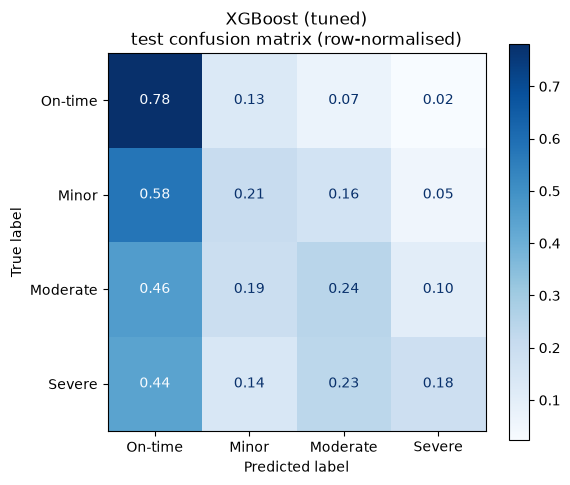

In [17]:
results_initial = dict(results) if "results" in globals() else None      # test result of the earlier (untuned) model, if Part 9 was run
prev_name, prev_model, prev_mult = best_name, best_model, best_multipliers

candidates = []                                                            # (label, model, multipliers, columns, val_score)
p_prev = get_proba(prev_name, prev_model, X_val[FEATURE_COLS] if prev_name != "RandomForest" else X_val)
candidates.append((f"{prev_name} (untuned, all features)", prev_model, prev_mult, list(FEATURE_COLS),
                   macro_f1_fast(y_val, (p_prev * prev_mult).argmax(1))))

for name, st in studies.items():
    t0 = time.time()
    m = FITTERS[name](st.best_params, FINAL_FEATURES)
    p = m.predict_proba(X_val[FINAL_FEATURES])
    w, s = tune_multipliers(p, y_val)
    candidates.append((f"{name} (tuned)", m, w, list(FINAL_FEATURES), s))
    print(f"{name} (tuned, {len(FINAL_FEATURES)} features): val macro-F1 {s:.4f}  [{time.time() - t0:.0f}s]")

final_table = pd.DataFrame([{"model": c[0], "n_features": len(c[3]), "val_macro_f1_tuned": c[4]}
                             for c in candidates if "untuned" not in c[0]])   # untuned models already listed from Part 7
final_table = (pd.concat([all_models_table[["model", "val_acc", "val_macro_f1", "val_macro_f1_tuned"]], final_table], ignore_index=True)
               .drop_duplicates("model", keep="last").sort_values("val_macro_f1_tuned", ascending=False).reset_index(drop=True))
display(final_table.round(4))
final_table.to_csv(OUTPUT_DIR / "final_model_selection.csv", index=False)

winner = max(candidates, key=lambda c: c[4])
best_label, best_model, best_multipliers, MODEL_FEATURES, _ = winner
best_name = best_label
print("\nFINAL MODEL:", best_name, "| features:", len(MODEL_FEATURES), "| multipliers:", np.round(best_multipliers, 2))

# ---- single test evaluation ----
if "X_test" not in globals():
    X_test = encode_features(make_features(test_df))
    y_test = make_labels(test_df)

proba_test = best_model.predict_proba(X_test[MODEL_FEATURES]) if "RandomForest" not in best_name \
    else best_model.predict_proba(X_test[MODEL_FEATURES].fillna(-999))
pred = (proba_test * best_multipliers).argmax(1)

results = {
    "accuracy": accuracy_score(y_test, pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, pred),
    "macro_f1": f1_score(y_test, pred, labels=LABELS, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, pred, labels=LABELS, average="weighted", zero_division=0),
    "macro_precision": precision_score(y_test, pred, labels=LABELS, average="macro", zero_division=0),
    "macro_recall": recall_score(y_test, pred, labels=LABELS, average="macro", zero_division=0),
    "mcc": matthews_corrcoef(y_test, pred),
    "baseline_macro_f1_always_ontime": macro_f1_fast(y_test, np.zeros(len(y_test), dtype=int)),
}
print("\n=== FINAL TEST RESULTS:", best_name, "===")
for k, v in results.items():
    print(f"{k:34s}: {v:.4f}")
if results_initial:
    print("\nEarlier (untuned) model on the same test set: macro-F1 =", round(results_initial["macro_f1"], 4))

report = classification_report(y_test, pred, labels=LABELS, target_names=CLASS_NAMES, digits=4, zero_division=0)
print("\n" + report)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred, labels=LABELS, normalize="true"),
                       display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", values_format=".2f")
ax.set_title(f"{best_name}\ntest confusion matrix (row-normalised)")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "confusion_matrix_test_final.png", dpi=150); plt.show()

with open(OUTPUT_DIR / "test_report_final.txt", "w") as f:
    f.write(f"Final model: {best_name}\nFeatures: {len(MODEL_FEATURES)}\n{pd.Series(results).to_string()}\n\n{report}")
pd.DataFrame([{"stage": "initial (Part 9)", **(results_initial or {})},
              {"stage": "final (tuned / selected)", **results}]).to_csv(OUTPUT_DIR / "test_initial_vs_final.csv", index=False)

## Part 16 - Updated export for the backend (replaces the old Part 10)
Run this once after Part 15. It saves the FINAL model, its feature list and the preprocessing objects into `backend/artifacts/`. Then restart the backend (`python app.py`). **No change to `app.py` or `index.html` is needed**: they read everything from the saved files, and they handle a smaller feature set automatically.

In [18]:
import json

BACKEND_DIR = PROJECT_DIR / "backend"
ART = BACKEND_DIR / "artifacts"
ART.mkdir(parents=True, exist_ok=True)

model_features = list(MODEL_FEATURES) if "MODEL_FEATURES" in globals() else list(FEATURE_COLS)

joblib.dump({"model": best_model, "model_name": best_name, "multipliers": best_multipliers,
             "class_w": class_w, "features": model_features, "encoder": encoder,
             "cat_cols": CAT_COLS, "class_names": CLASS_NAMES}, ART / "model_bundle.joblib")

np.savez_compressed(ART / "context_tables.npz",
                    apt_n=apt_cum[0], apt_s=apt_cum[1], apt_l=apt_cum[2],
                    car_n=car_cum[0], car_s=car_cum[1], car_l=car_cum[2])

coords = {}
for a_col, lat, lon in [("ORIGIN", "O_LATITUDE", "O_LONGITUDE"), ("DEST", "D_LATITUDE", "D_LONGITUDE")]:
    g = df.groupby(a_col)[[lat, lon]].median()
    for code, row in g.iterrows():
        if np.isfinite(row[lat]) and np.isfinite(row[lon]):
            coords.setdefault(str(code), [float(row[lat]), float(row[lon])])

route_dur = {f"{o}-{d}": float(v)
             for (o, d), v in df.groupby(["ORIGIN", "DEST"])["CRS_ELAPSED_TIME"].median().items() if np.isfinite(v)}

weather_by_airport_month = {}
for side, key, cols in [("O", "ORIGIN", ["O_TEMP", "O_PRCP", "O_WSPD"]), ("D", "DEST", ["D_TEMP", "D_PRCP", "D_WSPD"])]:
    g = df.groupby([key, "MONTH"])[cols].median()
    for (code, m), row in g.iterrows():
        weather_by_airport_month[f"{side}|{code}|{int(m)}"] = [float(v) if np.isfinite(v) else None for v in row.values]

weather_cols = ["O_TEMP", "O_PRCP", "O_WSPD", "D_TEMP", "D_PRCP", "D_WSPD"]
table_for_meta = final_table if "final_table" in globals() else comparison
meta = {
    "airport_order": [str(a) for a in airports], "carrier_order": [str(c) for c in carriers],
    "coords": coords, "route_dur": route_dur,
    "weather_by_airport_month": weather_by_airport_month,
    "weather_global": {c: float(df[c].median()) for c in weather_cols},
    "weather_range": {c: [float(df[c].min()), float(df[c].max())] for c in weather_cols},
    "start_date": str(START.date()), "H": int(H), "lag_h": int(LAG_H), "windows": list(WINDOWS),
    "date_min": str(df["FL_DATE"].min().date()), "date_max": str(df["FL_DATE"].max().date()),
    "test_metrics": {k: float(v) for k, v in results.items()} if "results" in globals() else None,
    "validation_table": json.loads(table_for_meta.round(4).to_json(orient="records")),
}
with open(ART / "meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f)

print("Final model exported:", best_name, "|", len(model_features), "features")
for p in sorted(ART.iterdir()):
    print(f"  {p.name:25s} {p.stat().st_size / 1e6:6.1f} MB")

Final model exported: XGBoost (tuned) | 41 features
  context_tables.npz           5.5 MB
  meta.json                    0.3 MB
  model_bundle.joblib          5.1 MB
